Final Project Recommendations
High-Value Retention: Since churned customers actually spend more than retained ones, we need a VIP "Save" program for high-spenders who log a complaint.

The 6-Month Milestone: Our data shows a drop-off before 6 months. We should implement a "Loyalty Discount" that unlocks at the 6-month mark to encourage users to stay.

Customer Service Audit: Complaints are a primary driver of churn. We need to investigate why the support team isn't resolving issues effectively enough to keep the customer.

In [5]:
# Create a summary table of averages
summary = df.groupby('Churn_Status').agg({
    'Tenure': 'mean',
    'HourSpendOnApp': 'mean',
    'TotalSpend': 'mean',
    'SatisfactionScore': 'mean'
}).round(2)

print("--- Executive Summary Profile ---")
display(summary)

# Calculate the official Churn Rate for the report
churn_rate = (df['Churn'].mean() * 100).round(2)
print(f"\nFINAL METRIC: Total Churn Rate is {churn_rate}%")

--- Executive Summary Profile ---


,Tenure,HourSpendOnApp,TotalSpend,SatisfactionScore
Churn_Status,,,,
Churned,5.59,2.55,301.94,3.35
Retained,7.91,2.58,295.84,3.21



FINAL METRIC: Total Churn Rate is 32.92%


C:\Users\Ryzen 4650G\AppData\Local\Temp\ipykernel_10564\3605036162.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Churn_Status', y='Tenure', palette='pastel', ax=ax[1])


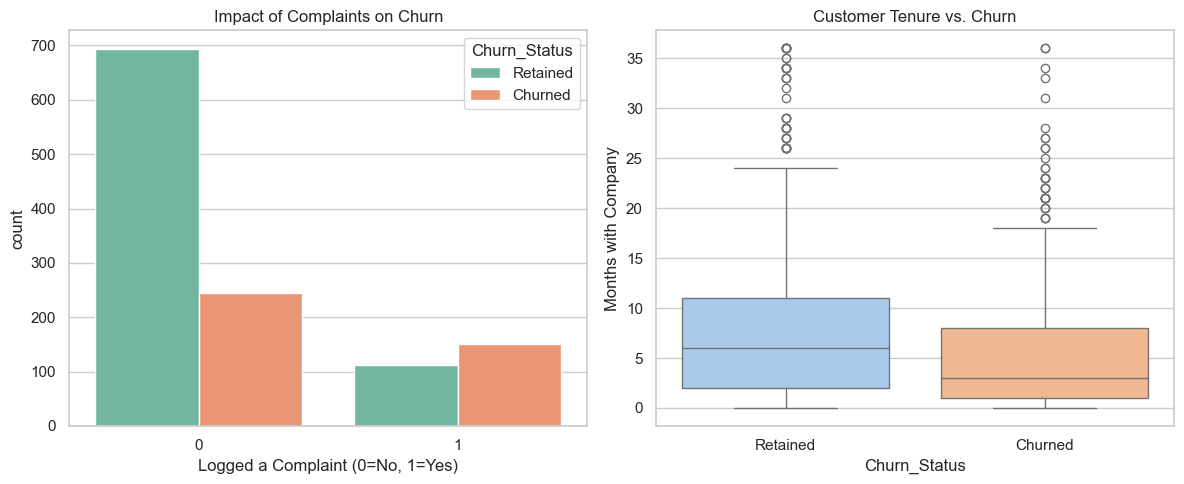

In [4]:
# Set the visual style
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 5)

# Create a figure with two side-by-side plots
fig, ax = plt.subplots(1, 2)

# Chart 1: Do complaints lead to churn?
sns.countplot(data=df, x='Complain', hue='Churn_Status', palette='Set2', ax=ax[0])
ax[0].set_title('Impact of Complaints on Churn')
ax[0].set_xlabel('Logged a Complaint (0=No, 1=Yes)')

# Chart 2: How does loyalty (Tenure) affect churn?
sns.boxplot(data=df, x='Churn_Status', y='Tenure', palette='pastel', ax=ax[1])
ax[1].set_title('Customer Tenure vs. Churn')
ax[1].set_ylabel('Months with Company')

plt.tight_layout()
plt.show()

In [3]:
# 1. Fill Missing Values
# We assume missing Tenure means 0 (brand new)
df['Tenure'] = df['Tenure'].fillna(0)

# We fill missing HourSpendOnApp with the median (middle) value
df['HourSpendOnApp'] = df['HourSpendOnApp'].fillna(df['HourSpendOnApp'].median())

# 2. Convert CustomerID to string
df['CustomerID'] = df['CustomerID'].astype(str)

# 3. Create 'TotalSpend' column
df['TotalSpend'] = df['AverageSpend'] * df['TotalOrders']

# 4. Create a readable Churn label
df['Churn_Status'] = df['Churn'].map({1: 'Churned', 0: 'Retained'})

# Verify the fixes
print("--- Check Missing Values Again ---")
print(df.isnull().sum())
print("\n--- New Column Preview ---")
display(df[['CustomerID', 'TotalSpend', 'Churn_Status']].head())

--- Check Missing Values Again ---
CustomerID           0
Tenure               0
HourSpendOnApp       0
AverageSpend         0
TotalOrders          0
SatisfactionScore    0
Complain             0
Churn                0
TotalSpend           0
Churn_Status         0
dtype: int64

--- New Column Preview ---


,CustomerID,TotalSpend,Churn_Status
0,10001,240.84,Retained
1,10002,402.00,Churned
2,10003,392.35,Retained
3,10004,525.63,Retained
4,10005,170.19,Retained


In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Load the data we just created
df = pd.read_csv("ecommerce_customer_data.csv")

# 2. See the first 5 rows
print("--- First 5 Rows of Data ---")
display(df.head())

# 3. Check for missing values and data types
print("\n--- Data Summary ---")
df.info()

# 4. See the "Churn" vs "Retained" count
print("\n--- Churn Count ---")
print(df['Churn'].value_counts())

--- First 5 Rows of Data ---


,CustomerID,Tenure,HourSpendOnApp,AverageSpend,TotalOrders,SatisfactionScore,Complain,Churn
0,10001,3.0,4.2,80.28,3,4,0,0
1,10002,24.0,2.4,80.40,5,5,1,1
2,10003,10.0,1.9,78.47,5,3,0,0
3,10004,7.0,4.6,75.09,7,1,1,0
4,10005,1.0,0.9,56.73,3,2,0,0



--- Data Summary ---
<class 'pandas.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         1200 non-null   int64  
 1   Tenure             1140 non-null   float64
 2   HourSpendOnApp     1152 non-null   float64
 3   AverageSpend       1200 non-null   float64
 4   TotalOrders        1200 non-null   int64  
 5   SatisfactionScore  1200 non-null   int64  
 6   Complain           1200 non-null   int64  
 7   Churn              1200 non-null   int64  
dtypes: float64(3), int64(5)
memory usage: 75.1 KB

--- Churn Count ---
Churn
0    805
1    395
Name: count, dtype: int64


In [1]:
import pandas as pd
import numpy as np

# 1. Set the scale of our project
np.random.seed(42)
num_customers = 1200
print("Generating customer data... please wait.")

# 2. Create the raw data features
customer_ids = np.arange(10001, 10001 + num_customers)
tenure = np.random.exponential(scale=8, size=num_customers).astype(int)
tenure = np.clip(tenure, 0, 36)

hours_on_app = np.random.normal(loc=2.5, scale=1.1, size=num_customers)
hours_on_app = np.clip(hours_on_app, 0.5, 6.0).round(1)

avg_spend = np.random.gamma(shape=3, scale=20, size=num_customers).round(2)
total_orders = np.random.poisson(lam=4, size=num_customers) + 1
satisfaction_score = np.random.choice([1, 2, 3, 4, 5], size=num_customers, p=[0.1, 0.15, 0.3, 0.3, 0.15])
complaints = np.random.choice([0, 1], size=num_customers, p=[0.78, 0.22])

# 3. Logic to determine who Churns (to make the analysis realistic)
churn_prob = 0.15 + (complaints * 0.35) 
churn_prob += np.where(tenure <= 3, 0.25, 0.0)
churn_prob = np.clip(churn_prob, 0.02, 0.95)
churn = np.random.binomial(n=1, p=churn_prob)

# 4. Assemble the table
df = pd.DataFrame({
    'CustomerID': customer_ids,
    'Tenure': tenure,
    'HourSpendOnApp': hours_on_app,
    'AverageSpend': avg_spend,
    'TotalOrders': total_orders,
    'SatisfactionScore': satisfaction_score,
    'Complain': complaints,
    'Churn': churn
})

# 5. Add some "dirty" data (missing values) for you to clean later
df.loc[df.sample(frac=0.05).index, 'Tenure'] = np.nan
df.loc[df.sample(frac=0.04).index, 'HourSpendOnApp'] = np.nan

# 6. SAVE THE FILE
df.to_csv("ecommerce_customer_data.csv", index=False)

print("--- SUCCESS ---")
print("File 'ecommerce_customer_data.csv' has been created in your folder.")
print("You can now proceed to Step 2: Loading and Analysis.")

Generating customer data... please wait.
--- SUCCESS ---
File 'ecommerce_customer_data.csv' has been created in your folder.
You can now proceed to Step 2: Loading and Analysis.
